Task 1 — Data Import & Setup
Import CSV using Pandas


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

df["posted_at"] = pd.to_datetime(df["posted_at"], dayfirst=True)
print("\nposted_at dtype after conversion:", df["posted_at"].dtype)

print("\nFirst 5 rows:")
print(df.head())

Shape: (5000, 19)

Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']

Data Types:
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object

posted_at dtype after conversion: datetime64[ns]

First 5 rows:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


Check/convert data types


In [ ]:
print(df.dtypes)

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


Convert date columns to datetime


In [ ]:
df["posted_at"] = pd.to_datetime(df["posted_at"], dayfirst=True)
print("\nposted_at dtype after conversion:", df["posted_at"].dtype)
print("\nFirst 5 rows:")
print(df.head())


posted_at dtype after conversion: datetime64[ns]

First 5 rows:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment     

Task 2 — Data Cleaning
●  Cleaning Missing Data
■ Detect missing values (isnull(), isna())

In [ ]:
print(df.isnull().sum())

print(df.isna().sum())

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


■ Handle using: dropna(), fillna(), median/mode, forward/backward-fill


In [ ]:
df = df.dropna()

In [ ]:
num_cols = ["age", "likes", "comments", "shares", "engagement_rate"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = ["gender", "country", "post_type", "sentiment"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df = df.ffill()

In [ ]:
df = df.bfill()

In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


● Duplicate Handling- Identify & remove duplicates


In [ ]:
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 0
Duplicate rows after removal: 0


In [ ]:
df["posted_at"] = pd.to_datetime(df["posted_at"], dayfirst=True)
df["is_verified"] = df["is_verified"].astype(bool)

df["gender"] = df["gender"].str.strip().str.lower()

df = df[df["likes"] >= 0]
df = df[df["comments"] >= 0]
df = df[df["shares"] >= 0]

● Data Formatting

In [ ]:
print("Data Types:\n", df.dtypes)

print("\nGender Labels:", df["gender"].unique())

print("\nNegative likes:", (df["likes"] < 0).sum())
print("Negative comments:", (df["comments"] < 0).sum())
print("Negative shares:", (df["shares"] < 0).sum())

Data Types:
 user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object

Gender Labels: ['female' 'male' 'other']

Negative likes: 0
Negative comments: 0
Negative shares: 0


●  Feature Cleaning

In [ ]:
df["hashtag_count"] = df["hashtags"].str.count("#")

df["sentiment"] = df["sentiment"].str.strip().str.lower()

print(df[["hashtags", "hashtag_count"]].head())
print(df["sentiment"].unique())

                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1
['negative' 'positive' 'neutral']


Task 3 — Data Exploration using Pandas
Perform the following:
● View dataset structure using head(), tail(), shape, and columns.

In [ ]:
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

First 5 rows:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  female      UK   109864      text          food   4862.0   
3    64886  51.0   other  France   848877      text       fitness   5350.0   
4    16265  34.0   other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        Fals

● Check data types and info with info() and dtypes.

In [ ]:
print(df.info())
print("\n")
print(df.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 4162 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4162 non-null   int64         
 1   age               4162 non-null   float64       
 2   gender            4162 non-null   object        
 3   country           4162 non-null   object        
 4   post_id           4162 non-null   int64         
 5   post_type         4162 non-null   object        
 6   post_category     4162 non-null   object        
 7   likes             4162 non-null   float64       
 8   comments          4162 non-null   float64       
 9   shares            4162 non-null   float64       
 10  watch_time_sec    4162 non-null   int64         
 11  impression_count  4162 non-null   int64         
 12  posted_at         4162 non-null   datetime64[ns]
 13  follower_count    4162 non-null   int64         
 14  is_verified       4162 non-nu

● Generate summary statistics using describe().

In [ ]:
print(df.describe())

            user_id          age        post_id         likes     comments  \
count   4162.000000  4162.000000    4162.000000   4162.000000  4162.000000   
mean   54317.294330    38.466362  548479.872417  10056.813551  1502.600913   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32174.750000    26.000000  324397.500000   4991.500000   764.250000   
50%    53878.000000    38.000000  551047.000000  10016.000000  1505.500000   
75%    77016.750000    51.000000  770129.500000  15056.500000  2258.000000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    25990.016175    14.896372  259331.476657   5792.668485   869.743640   

            shares  watch_time_sec  impression_count  \
count  4162.000000     4162.000000       4162.000000   
mean    999.359202     3988.097549      50050.542528   
min       0.000000        0.000000        105.000000   
25%     488.250000     1966.500000      24926.500000   
50%    1007.00000

● Analyze categorical distributions using value_counts(), unique(), and  
nunique().

In [ ]:
print("Gender distribution:\n", df["gender"].value_counts())

print("\nUnique countries:\n", df["country"].unique())

print("\nNumber of unique countries:", df["country"].nunique())

print("\nPost type distribution:\n", df["post_type"].value_counts())

print("\nSentiment categories:\n", df["sentiment"].unique())

Gender distribution:
 gender
male      1477
female    1354
other     1331
Name: count, dtype: int64

Unique countries:
 ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE' 'USA'
 'Germany']

Number of unique countries: 10

Post type distribution:
 post_type
reel     1065
image    1044
text     1035
video    1018
Name: count, dtype: int64

Sentiment categories:
 ['negative' 'positive' 'neutral']


● Create a correlation matrix for numeric fields.

In [ ]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.016610  0.014552  0.035584 -0.026360  0.010624   
age              -0.016610  1.000000 -0.009944 -0.037100 -0.011132  0.012808   
post_id           0.014552 -0.009944  1.000000  0.013925 -0.014432  0.005733   
likes             0.035584 -0.037100  0.013925  1.000000 -0.016923  0.004428   
comments         -0.026360 -0.011132 -0.014432 -0.016923  1.000000  0.008826   
shares            0.010624  0.012808  0.005733  0.004428  0.008826  1.000000   
watch_time_sec   -0.021526  0.008402  0.023821  0.000579 -0.019330  0.018717   
impression_count  0.009995  0.014665 -0.010847 -0.000887 -0.009390  0.003362   
follower_count    0.017189 -0.027001 -0.003109 -0.009989 -0.013134 -0.004357   
is_verified       0.006476 -0.009681  0.017425 -0.005128 -0.019028  0.007104   
engagement_rate  -0.000632  0.009695  0.009431  0.093356  0.002415  0.024374   
hashtag_count    -0.025727  0.002347  0.

● Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

In [ ]:
print("Average likes by post type:")
print(df.groupby("post_type")["likes"].mean())

print("\nAverage impressions by country:")
print(df.groupby("country")["impression_count"].mean())

Average likes by post type:
post_type
image    10078.105364
reel     10046.336150
text      9999.017391
video    10104.700393
Name: likes, dtype: float64

Average impressions by country:
country
Australia    47462.187648
Brazil       49606.840000
Canada       48475.293981
France       51330.009501
Germany      48648.537084
India        52689.146341
Japan        50202.933673
UAE          48703.443099
UK           51303.958937
USA          51931.131841
Name: impression_count, dtype: float64


 Task 4 — Data Wrangling  
● Use merge, concat, or join if combining DataFrames.

In [ ]:
df_users = df[["user_id", "age", "gender", "country"]]

df_posts = df[["user_id", "post_type", "likes", "comments", "shares"]]

merged_df = pd.merge(df_users, df_posts, on="user_id")

print(merged_df.head())

   user_id   age  gender country post_type    likes  comments  shares
0    25795  43.0  female  Brazil     image   7011.0     354.0  1157.0
1    10860  33.0    male  Brazil      reel  11750.0    2606.0  1807.0
2    86820  32.0  female      UK      text   4862.0     344.0   955.0
3    64886  51.0   other  France      text   5350.0    1083.0  1049.0
4    16265  34.0   other      UK     image  12682.0    2735.0  1300.0


● Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.

In [ ]:
df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]

print(df[["likes", "comments", "shares", "engagement_score"]].head())

     likes  comments  shares  engagement_score
0   7011.0     354.0  1157.0            8522.0
1  11750.0    2606.0  1807.0           16163.0
2   4862.0     344.0   955.0            6161.0
3   5350.0    1083.0  1049.0            7482.0
4  12682.0    2735.0  1300.0           16717.0


● Perform groupby summaries by post_type, country, and sentiment.

In [ ]:
import numpy as np

df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]

df["log_likes"] = np.log1p(df["likes"])

df["hashtag_count"] = df["hashtags"].str.count("#")

print(df[["engagement_score", "log_likes", "hashtag_count"]].head())

   engagement_score  log_likes  hashtag_count
0            8522.0   8.855378              3
1           16163.0   9.371694              1
2            6161.0   8.489411              1
3            7482.0   8.585039              3
4           16717.0   9.448018              1


In [ ]:
print("Average engagement score by post type:")
print(df.groupby("post_type")["engagement_score"].mean())

print("\nAverage engagement rate by country:")
print(df.groupby("country")["engagement_rate"].mean())

print("\nAverage likes by sentiment:")
print(df.groupby("sentiment")["likes"].mean())

Average engagement score by post type:
post_type
image    12605.627395
reel     12538.156808
text     12513.562319
video    12578.258350
Name: engagement_score, dtype: float64

Average engagement rate by country:
country
Australia    1.462492
Brazil       1.637193
Canada       0.927467
France       1.250086
Germany      0.817767
India        0.690853
Japan        0.794976
UAE          1.116916
UK           0.872840
USA          0.549766
Name: engagement_rate, dtype: float64

Average likes by sentiment:
sentiment
negative    10116.993954
neutral      9937.506454
positive    10110.013875
Name: likes, dtype: float64


Task 5 — Statistical Analysis  
Compute descriptive stats for “likes, comments, shares, watch_time,
engagement_rate, followers” columns ● Mean, median, mode


In [ ]:
cols = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

print("Mean:\n", df[cols].mean())
print("\nMedian:\n", df[cols].median())
print("\nMode:\n", df[cols].mode().iloc[0])
print("\nStandard Deviation:\n", df[cols].std())
print("\nVariance:\n", df[cols].var())
print("\nPercentiles:\n", df[cols].quantile([0.25, 0.50, 0.75]))

Mean:
 likes               10056.813551
comments             1502.600913
shares                999.359202
watch_time_sec       3988.097549
engagement_rate         1.015154
follower_count     394707.644402
dtype: float64

Median:
 likes               10016.000000
comments             1505.500000
shares               1007.000000
watch_time_sec       4010.500000
engagement_rate         0.253054
follower_count     390905.500000
dtype: float64

Mode:
 likes               13536.000000
comments             1806.000000
shares                138.000000
watch_time_sec       4360.000000
engagement_rate         0.006363
follower_count     497502.000000
Name: 0, dtype: float64

Standard Deviation:
 likes                5792.668485
comments              869.743640
shares                580.989352
watch_time_sec       2312.095707
engagement_rate         5.748086
follower_count     231315.725822
dtype: float64

Variance:
 likes              3.355501e+07
comments           7.564540e+05
shares          

● Standard deviation, variance

In [ ]:
cols = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

print("Standard Deviation:\n", df[cols].std())

print("\nVariance:\n", df[cols].var())

Standard Deviation:
 likes                5792.668485
comments              869.743640
shares                580.989352
watch_time_sec       2312.095707
engagement_rate         5.748086
follower_count     231315.725822
dtype: float64

Variance:
 likes              3.355501e+07
comments           7.564540e+05
shares             3.375486e+05
watch_time_sec     5.345787e+06
engagement_rate    3.304049e+01
follower_count     5.350697e+10
dtype: float64


● Percentiles

In [ ]:
percentiles = df[cols].quantile([0.25, 0.50, 0.75])

print(percentiles)

        likes  comments   shares  watch_time_sec  engagement_rate  \
0.25   4991.5    764.25   488.25         1966.50         0.144968   
0.50  10016.0   1505.50  1007.00         4010.50         0.253054   
0.75  15056.5   2258.00  1499.00         5990.75         0.502043   

      follower_count  
0.25       195597.75  
0.50       390905.50  
0.75       589908.50  


●  Skewness and kurtosis

In [ ]:
shape_summary = pd.DataFrame({
    "Skewness": df[cols].skew(),
    "Kurtosis": df[cols].kurt()
})

print(shape_summary)

                  Skewness    Kurtosis
likes             0.001169   -1.205249
comments          0.002039   -1.200768
shares           -0.009028   -1.208517
watch_time_sec   -0.006841   -1.208625
engagement_rate  17.751400  423.834703
follower_count    0.037005   -1.185274


Task 6 — Data Visualization
● Matplotlib

Scatter

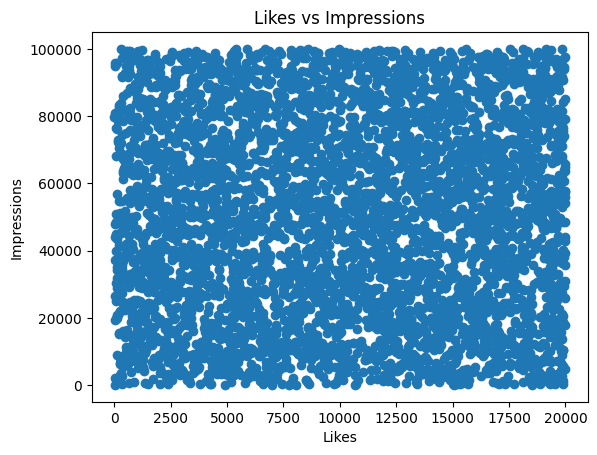

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.figure()
plt.scatter(df["likes"], df["impression_count"])
plt.title("Likes vs Impressions")
plt.xlabel("Likes")
plt.ylabel("Impressions")
plt.show()

Line

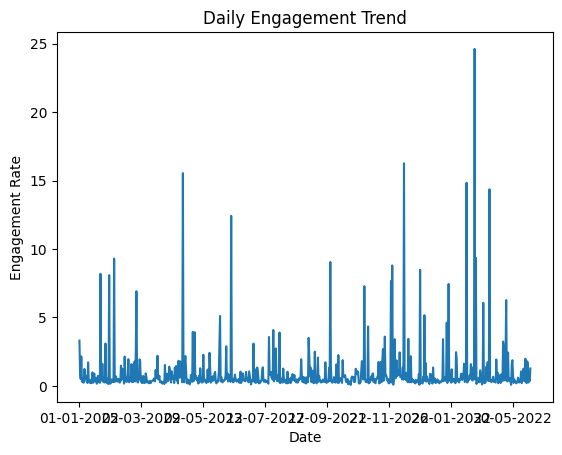

In [ ]:
daily_eng = df.groupby("posted_at")["engagement_rate"].mean()

plt.figure()
daily_eng.plot()
plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Engagement Rate")
plt.show()

Bar

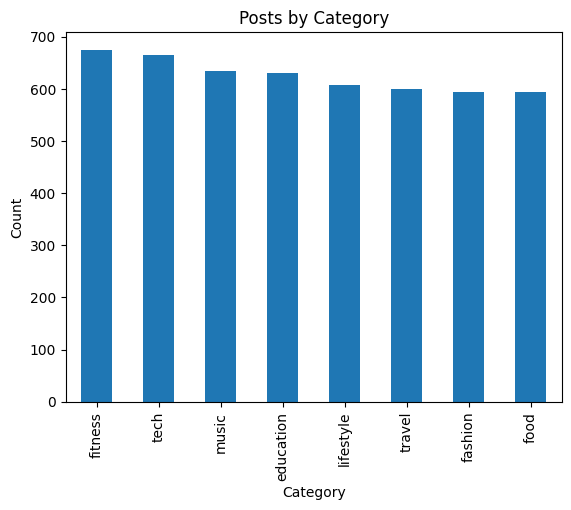

In [ ]:
plt.figure()
df["post_category"].value_counts().plot(kind="bar")
plt.title("Posts by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

Pie

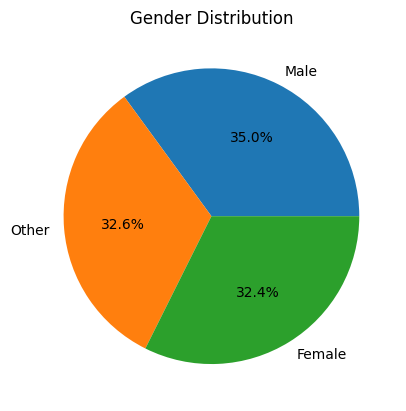

In [ ]:
plt.figure()
df["gender"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

Histogram

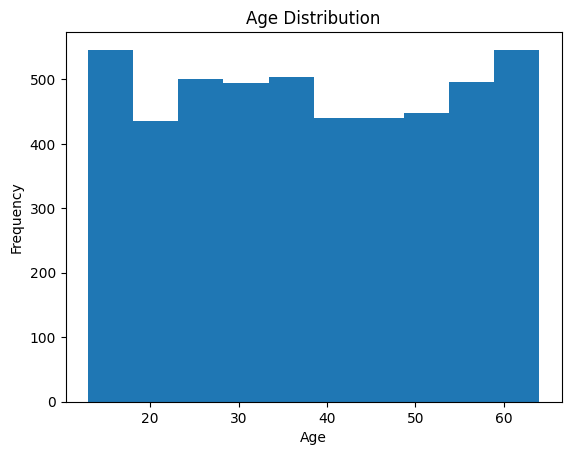

In [ ]:
plt.figure()
plt.hist(df["age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Box

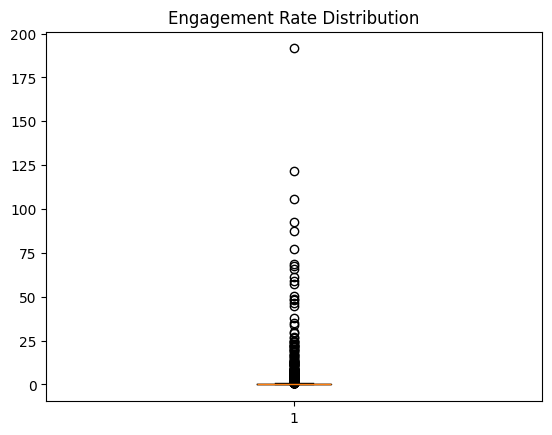

In [ ]:
plt.figure()
plt.boxplot(df["engagement_rate"])
plt.title("Engagement Rate Distribution")
plt.show()

Seaborn

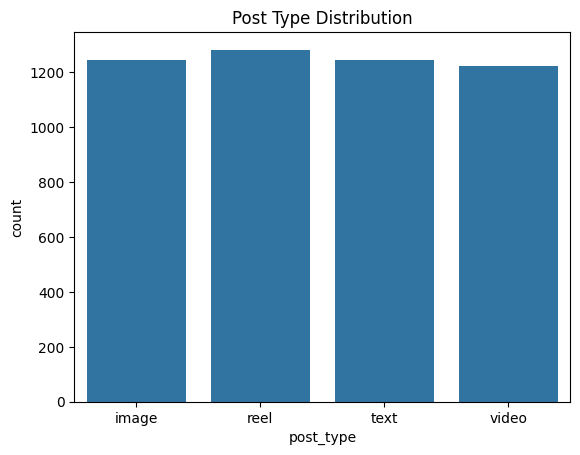

In [ ]:
plt.figure()
sns.countplot(x="post_type", data=df)
plt.title("Post Type Distribution")
plt.show()

Bar Plot

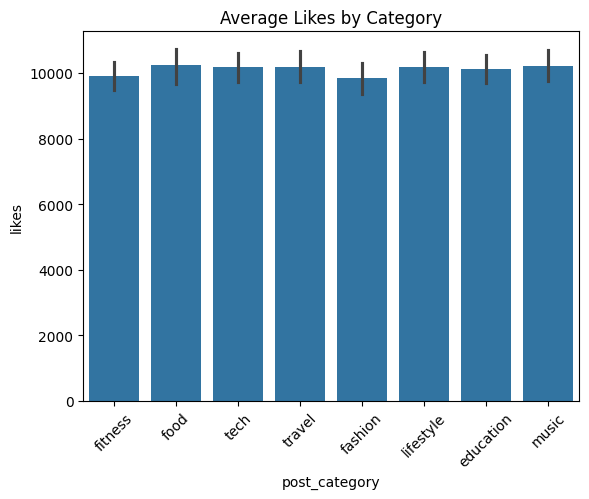

In [ ]:
plt.figure()
sns.barplot(x="post_category", y="likes", data=df)
plt.title("Average Likes by Category")
plt.xticks(rotation=45)
plt.show()

Violin Plot

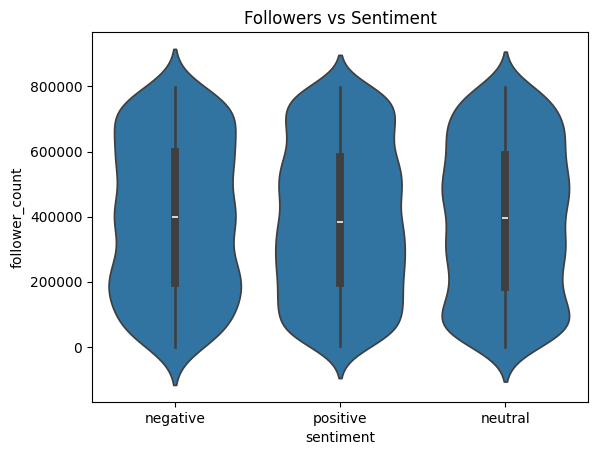

In [ ]:
plt.figure()
sns.violinplot(x="sentiment", y="follower_count", data=df)
plt.title("Followers vs Sentiment")
plt.show()

Pair Plot

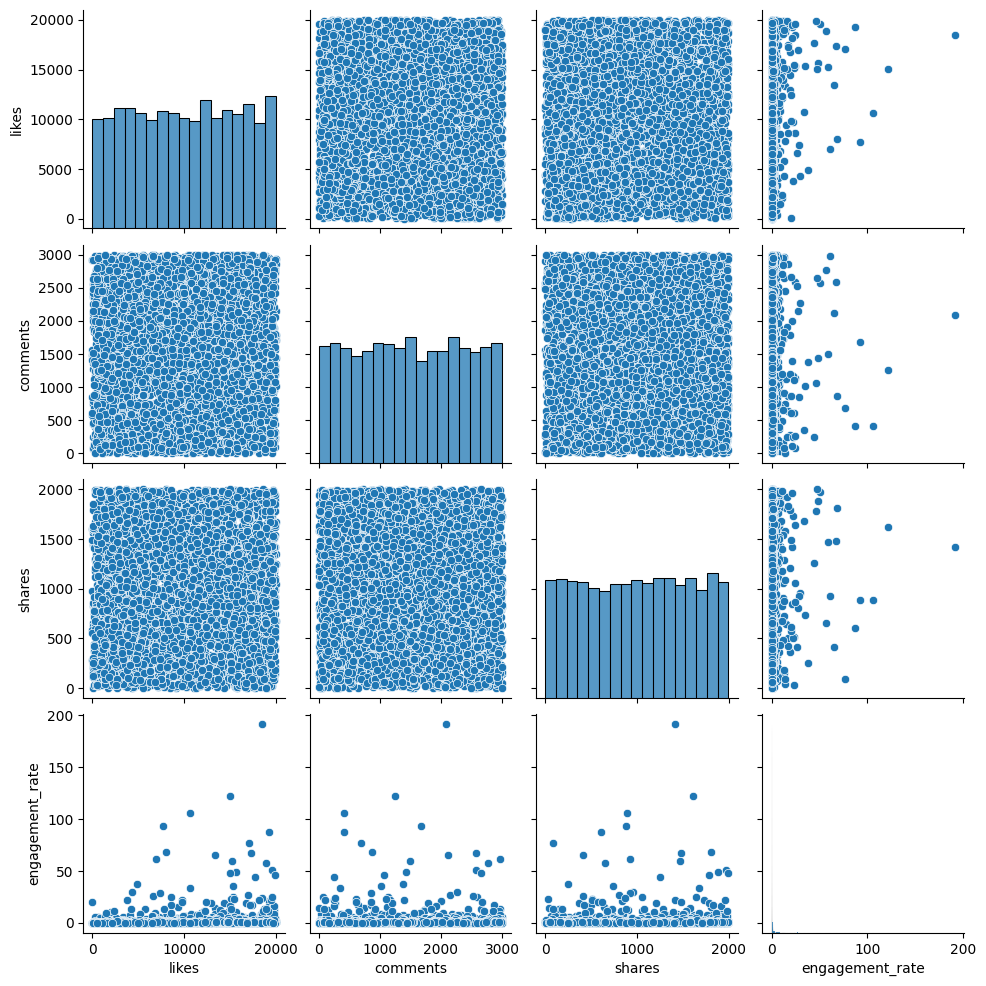

In [ ]:
sns.pairplot(df[["likes","comments","shares","engagement_rate"]])
plt.show()

Heatmap

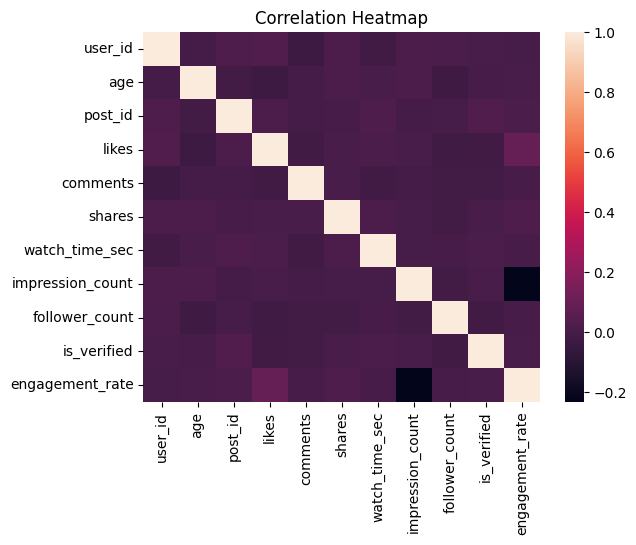

In [ ]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.show()

Swarm Plot

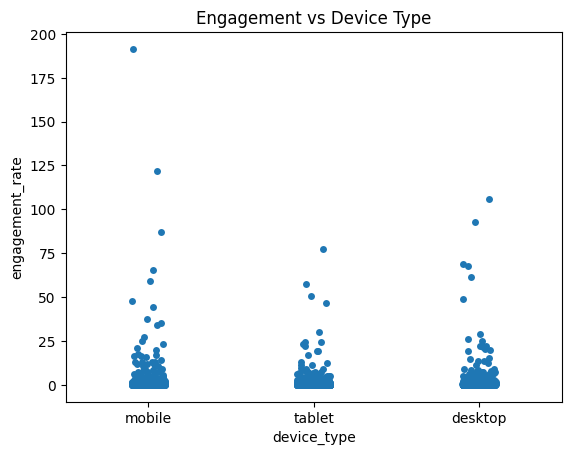

In [ ]:
plt.figure()
sns.stripplot(x="device_type", y="engagement_rate", data=df)
plt.title("Engagement vs Device Type")
plt.show()

Plotly

In [ ]:
fig = px.scatter(df, x="likes", y="impression_count")
fig.show()